#### Test Case: Isobaric evaporation of LNH3 in a 5059 m3 storage tank filled at 95% of its capacity
- Phase shift of heat transfer rates between no wall model & wall of thickness $e_w$
- Different thicknesses of bottom & wall produce a phase shift, which dampens the maximum oscillation.
- The maximum oscillations in Q_tot occur when all heat ingresses are in phase.

In [13]:
# Scientific computing
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

## Module imports
# Import the storage tank Class
from cryoevap.storage_tanks import Tank

# Import Cryogen class
from cryoevap.cryogens import Cryogen

# Import Pandas for data handling
import pandas as pd

#### Setup tank and cryogen properties
- Modify e_w in line 3 to vary wall thickness

In [14]:
# LNG tank properties
Q_roof = 0           # Roof heat ingress / W
e_w    = 18*0.0254    # Wall thickness / m
d_i    = 10.24*2     # Internal diameter / m
d_o    = d_i + 2*e_w   # External diameter / m
T_air  = 5.3286+273.15 # Temperature of the environment K

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 0.087   # W/m2/K
U_V = 0.087   # W/m2/K
h_L = 124.96  # W/m2/K

# Set wall tank properties
Init_T = True   # True: T_air, False: T_L
k_w    = 0.0411 # W/mK
cp_w   = 900    # J/kg K
rho_w  = 60     # kg/m3

# Specify heat transfer rate at the bottom to prevent ground heating
Q_b = None # W, 

# Vertically orientated cylindrical tank volume
V_tank = 5059.889 #m^3

# Initial liquid filling / Dimensionless
LF = 0.95 

# Specify tank operating pressure
P = 101325 # Pa

# Initialize large-scale tank
large_tank = Tank(d_i, d_o, V_tank, LF)

large_tank.set_HeatTransProps(U_L, U_V, T_air, Q_b_fixed = None, Q_roof = 0, eta_w = 0.70, k_w = k_w, rho_w = rho_w, cp_w = cp_w, h_L = h_L, T_init = Init_T)

# Initialise cryogen
ammonia = Cryogen(name = "ammonia")
ammonia.set_coolprops(P)

# Set cryogen
large_tank.cryogen = ammonia

# Calculate initial evaporation rate
print("The initial evaporation rate of " + ammonia.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

The initial evaporation rate of ammonia is 11.9 kg/h


Calculate initial evaporation rate and transient period

In [15]:
# Calculate initial evaporation rate
print("The initial evaporation rate of " + ammonia.name + " is %.1f kg/h" % (large_tank.b_l_dot * 3600))

# Estimate transient period duration
print("Transient period = %.3f s " % large_tank.tau)

# Minimum number of hours to achieve steady state 
tau_h = (np.floor(large_tank.tau / 3600) + 1)

# Print simulation time of the transient period for short-term storage
print("Simulation time: %.0i h" % tau_h )

# Calculate boil-off rate
BOR = (large_tank.b_l_dot * 24 * 3600) / (large_tank.V * large_tank.LF * large_tank.cryogen.rho_L)
print("BOR = %.3f %%" % (BOR * 100))

The initial evaporation rate of ammonia is 11.9 kg/h
Transient period = 136264.000 s 
Simulation time: 38 h
BOR = 0.009 %


#### Setup environmental properties

In [16]:
T_env_avg = 5.3286+273.15     # K
T_range   = 15                # K
h_env     = 396               # W/m2K   

p_anual   = np.array([-0.00022, 0.08395, 0.989792])

large_tank.set_EnvironmentalProps(T_avg_day = T_env_avg, T_range_day = T_range, h_env = h_env,
                                  p_anual=None)

#### Simulation setup and execution

In [17]:
# Define vertical spacing
# Note: The location of the maximum is not highly affected by grid resolution
# For smooth profiles, use dz = 0.05 m,  dr = 0.005 m
# For quick estimates, use dz = 0.05 m,  dr = 0.01 m

dz = 0.05 # 
dr = 0.01 # 0.005

# Calculate number of nodes based on grid spacing
n_z = 1 + int(np.round(large_tank.l_V/dz, 0))
n_r = 1 + int(np.round((large_tank.d_o - large_tank.d_i)/(2*dr), 0))

# Define dimensionless computational grid
large_tank.z_grid = np.linspace(0, 1, n_z)

large_tank.r_grid = np.linspace(0, 1, n_r)

# Insulated roof
large_tank.U_roof = 0

# Define evaporation time as 48 h
evap_time = 3600 * 48

# Time step to record data, relevant for plotting integrated quantities
# such as the vapour to liquid heat transfer rate, Q_VL
large_tank.time_interval = 0.48 * 3600 

# Time step to plot each vapour temperature profile
large_tank.plot_interval = evap_time/6

# Simulate the evaporation
large_tank.evaporate(evap_time)

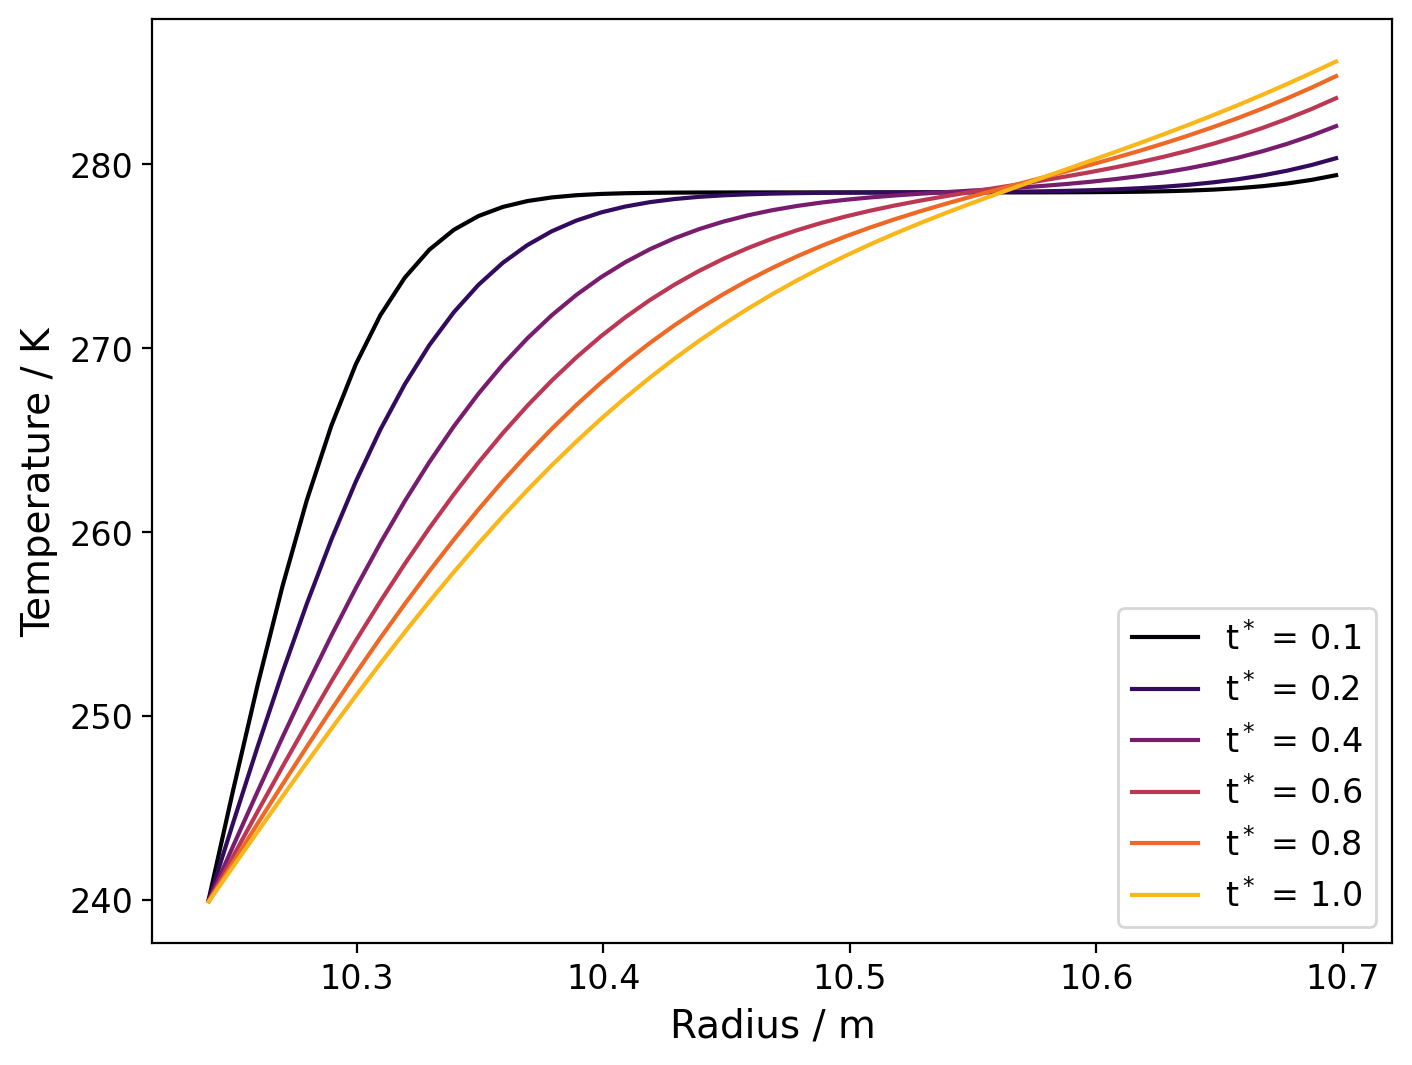

In [18]:
r = np.linspace(0, 1, large_tank.data['T_w_raw'].shape[0]) * (large_tank.d_o - large_tank.d_i)/2 + large_tank.d_i/2
time_tau = [1, 2, 4, 6, 8, 10]

cmap = plt.get_cmap('inferno', len(time_tau)+1)

plt.figure(figsize= (8,6), dpi=200)

for j, i in enumerate(time_tau):
    plt.plot(r, large_tank.data['T_w_raw'][:, i], label=fr't$^*$ = {i/10:.1f}', color = cmap(j))

plt.legend(fontsize = 12)
plt.xlabel('Radius / m', fontsize=14)
plt.ylabel('Temperature / K', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

#### Visualisation of results

#### Vapour temperature

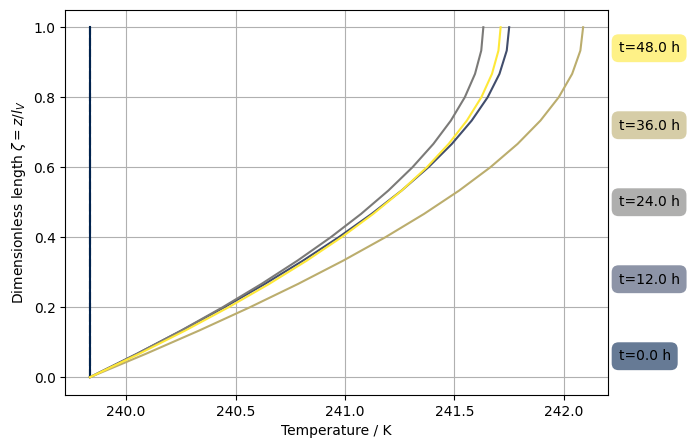

In [19]:
# Visualise the plot
large_tank.plot_tv(t_unit='h')

Visualise liquid and vapour heat ingresses, $\dot{Q}_{\text{L}}$ and  $\dot{Q}_{\text{V}}$.

The plot also shows the vapour to liquid heat ingress, $\dot{Q}_{VL}$, and  the partition of the vapour heat ingress that is transferred to the interface by the wall directly, $\dot{Q}_{\text{V,w}}$

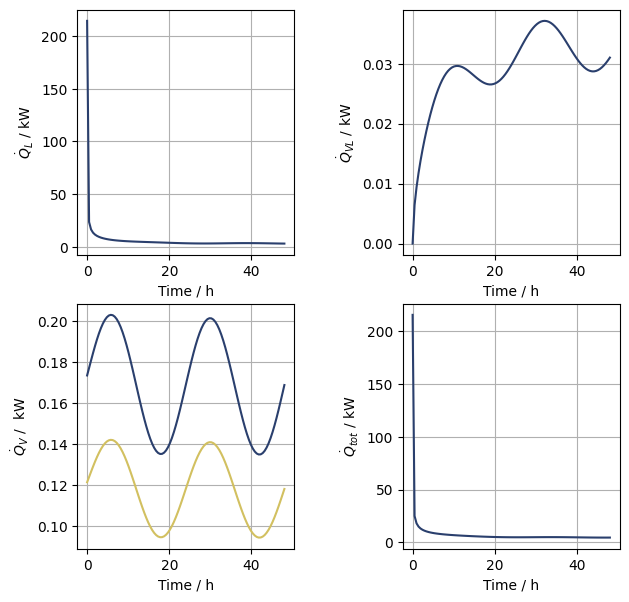

In [20]:
large_tank.plot_Q(unit='kW', t_unit='h')

#### Plot liquid volume

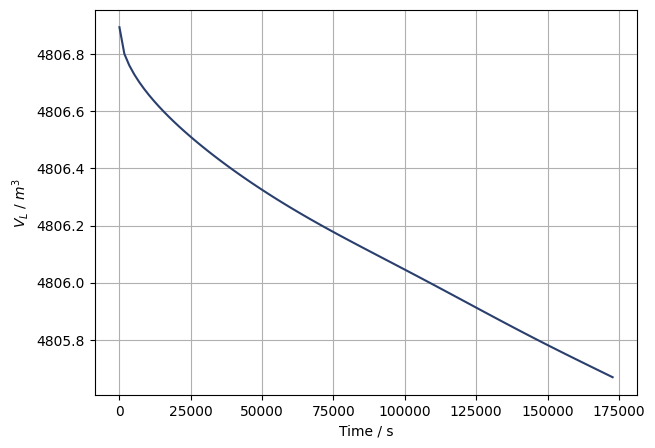

In [21]:
large_tank.plot_V_L()

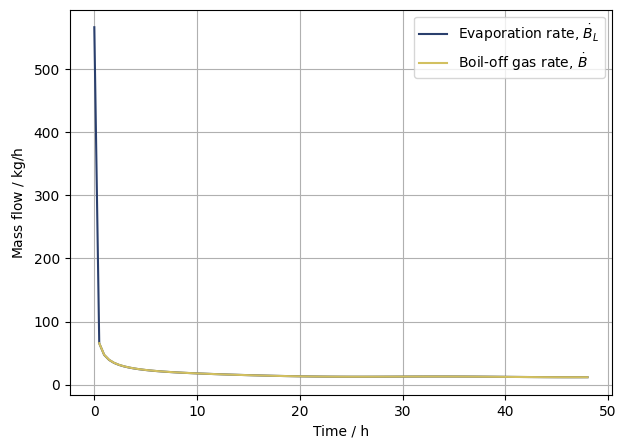

In [22]:
large_tank.plot_BOG(unit='kg/h', t_unit='h')

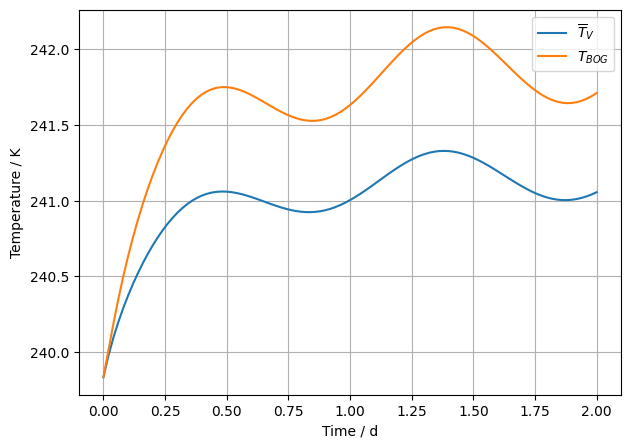

In [23]:
large_tank.plot_tv_BOG(t_unit='d')

#### Plot wall properties

LF = 0.95, Wall thickness r_o - r_i = 0.457 m
The transient period of wall heat conduction is 4.77 h
Phase shift (t_max(Q_L) - t_max(Q_L_noWall)) = 9.12 h


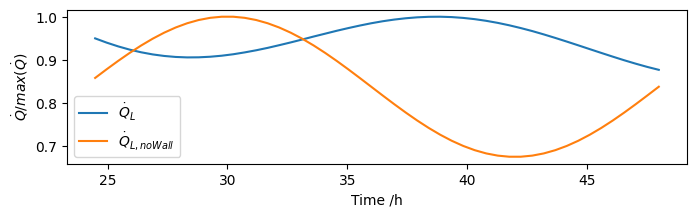

In [24]:
# Find maxima (peaks) in sinusoidal function
from scipy.signal import find_peaks

# Comparison with wall cooling transient period
# Characteristic length of heat transfer
l_c = (large_tank.d_o/2 - large_tank.d_i/2)
print("LF = %.2f, Wall thickness r_o - r_i = %.3f m" % (large_tank.LF, l_c))

# Transient time for heat conduction assuming small curvature
tau_w = l_c**2/(16*large_tank.alpha_w)/3600
print("The transient period of wall heat conduction is %.2f h" % tau_w)

# Identify the peaks after 75000 s
ss_idx = large_tank.data['Time'] > 86400
time_ss = large_tank.data['Time'][ss_idx]
Q_L = large_tank.data['Q_L'][ss_idx]
Q_L_nowall = large_tank.data['Q_L_inst'][ss_idx]
p_wall = find_peaks(Q_L)
p_noWall = find_peaks(Q_L_nowall)
phase_diff = (time_ss[p_wall[0][0]]-time_ss[p_noWall[0][0]])/3600
print("Phase shift (t_max(Q_L) - t_max(Q_L_noWall)) = %.2f h" % phase_diff)
plt.figure(figsize=[8,2])
plt.plot(time_ss/3600,Q_L/max(Q_L), label = r'$\dot{Q}_L$')
plt.plot(time_ss/3600,Q_L_nowall/max(Q_L_nowall) , label = r'$\dot{Q}_{L,noWall}$' )
plt.ylabel(r'$\dot{Q}/max(\dot{Q})$')
plt.xlabel('Time /h')
plt.legend()
plt.show()